# LRG, tSZ, CMB-lensing, and DES-kappa power spectra with NaMaster

This notebook follows the LRG selection in `test_lrg_Cls_namaster.ipynb`, then measures `Cl_gg`, `Cl_gkappa_DES`, `Cl_gkappa_CMB`, `Cl_yg`, `Cl_ykappa_DES`, and `Cl_yy` with NaMaster. The saved pickle contains the measured bandpowers, bandpower windows, per-spectrum covariance blocks, and the full Gaussian joint covariance across the requested spectra.

The LRG fields are pixelized overdensity maps rather than `NmtFieldCatalogClustering` objects because the installed NaMaster covariance workspace requires compatible pixelized fields for mixed map/catalog Gaussian covariance.

In [1]:
%load_ext autoreload
%autoreload 2
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

from dataclasses import asdict
from datetime import datetime, timezone
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

cwd = Path.cwd()
if (cwd / "xdesi_namaster_xcorr_utils.py").exists():
    XDESI_DIR = cwd
elif (cwd / "notebooks/xDESI/xdesi_namaster_xcorr_utils.py").exists():
    XDESI_DIR = cwd / "notebooks/xDESI"
else:
    raise RuntimeError("Could not locate xdesi_namaster_xcorr_utils.py")

if str(XDESI_DIR) not in sys.path:
    sys.path.insert(0, str(XDESI_DIR))

from xdesi_namaster_xcorr_utils import (
    LrgCuts,
    MeasurementConfig,
    XcorrPaths,
    build_scalar_fields,
    compute_lrg_nz,
    load_lrg_catalog,
    load_lrg_randoms,
    measure_target_spectra_and_covariances,
    plot_all_target_spectra,
    plot_nz,
    save_measurement_pickle,
)

plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 150})

## Configuration

In [2]:
paths = XcorrPaths()
cuts = LrgCuts(
    min_nobs=2,
    max_ebv=0.15,
    max_stardens=2500.0,
)

config = MeasurementConfig(
    nside=1024,
    lmax=2048,
    nlb=100,
    nbins_gal=4,
    y_downgrade=2,
    cmb_kappa_mask_power=2.0,
    subtract_masked_mean=True,
    compute_full_joint_covariance=True,
    output_pickle="outputs/lrg_tsz_shear_cls_namaster.pkl",
)

output_path = XDESI_DIR / config.output_pickle
path_files = {
    key: str(getattr(paths, key))
    for key in [
        "lrg_catalog",
        "lrg_weights",
        "lrg_random_mask",
        "stardens_map",
        "randoms_catalog",
        "cmb_kappa_alm",
        "cmb_kappa_mask",
        "des_kappa_map",
        "des_mask",
        "y_map",
        "y_mask",
    ]
}
print(f"xDESI notebook dir: {XDESI_DIR}")
print(f"Output pickle: {output_path}")
print(f"nside={config.nside}, lmax={config.resolved_lmax()}, nlb={config.nlb}")

xDESI notebook dir: /mnt/ceph/users/spandey/ltu-godmax/GODMAX/notebooks/xDESI
Output pickle: /mnt/ceph/users/spandey/ltu-godmax/GODMAX/notebooks/xDESI/outputs/lrg_tsz_shear_cls_namaster.pkl
nside=1024, lmax=2048, nlb=100


## Select DESI LRGs and matching randoms

The cuts below match the template notebook: remove the small NGC islands, require `NOBS_G/R/Z >= 2`, apply `lrg_mask == 0`, require `EBV < 0.15`, and remove pixels above the stellar-density threshold.

In [3]:
cat, data_cutflow = load_lrg_catalog(paths, cuts, verbose=True)
randoms, random_cutflow = load_lrg_randoms(paths, cuts, verbose=True)


LRG data cutflow
  Remove NGC islands   kept=12,315,675 removed=    76,534 kept_fraction=0.99382
  NOBS                 kept=11,733,330 removed=   582,345 kept_fraction=0.95272
  LRG mask             kept=10,355,201 removed= 1,378,129 kept_fraction=0.88255
  EBV                  kept=10,225,401 removed=   129,800 kept_fraction=0.98747
  STARDENS             kept= 9,996,023 removed=   229,378 kept_fraction=0.97757
Selected LRGs: 9,996,023

LRG randoms cutflow
  Target NOBS          kept=49,302,231 removed= 2,436,385 kept_fraction=0.95291
  Target MASKBITS      kept=48,794,148 removed=   508,083 kept_fraction=0.98969
  Remove NGC islands   kept=48,521,151 removed=   272,997 kept_fraction=0.99441
  NOBS                 kept=46,551,546 removed= 1,969,605 kept_fraction=0.95941
  LRG mask             kept=43,050,347 removed= 3,501,199 kept_fraction=0.92479
  EBV                  kept=42,544,901 removed=   505,446 kept_fraction=0.98826
  STARDENS             kept=41,618,870 removed=   926,03

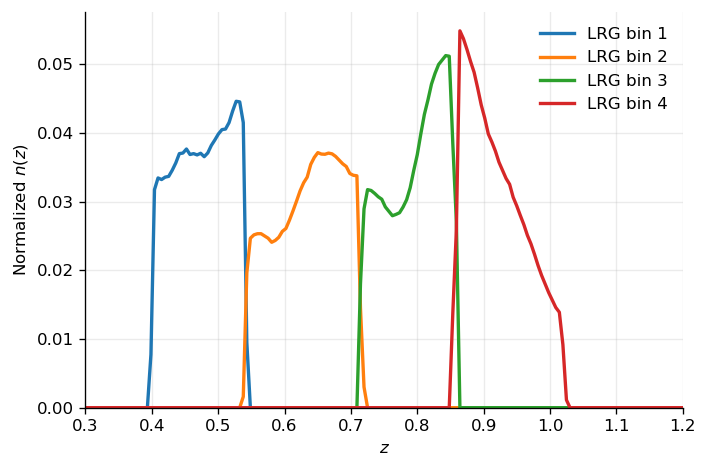

In [4]:
nz = compute_lrg_nz(cat, config)
fig, ax = plt.subplots(figsize=(6, 4))
plot_nz(nz, config.nbins_gal, ax=ax)
fig.tight_layout()

## Build NaMaster fields

All fields are scalar HEALPix `NmtField` objects at the same `nside` and `lmax`. For each LRG bin, the helper builds a weighted overdensity map using the random catalog footprint and stores the Poisson shot-noise level used to subtract `Cl_gg` bandpowers.

In [5]:
fields = build_scalar_fields(cat, randoms, paths, config, verbose=True)

for name, sf in fields.items():
    meta = sf.metadata
    print(
        f"{name:>10s}: mask={sf.mask_name:<10s} "
        f"shot_noise={sf.shot_noise:.4e} "
        f"weighted_fsky={meta.get('weighted_fsky', meta.get('fsky', np.nan)):.4f}"
    )

Building LRG random footprint mask


Building LRG overdensity field for bin 1
Building LRG overdensity field for bin 2
Building LRG overdensity field for bin 3
Building LRG overdensity field for bin 4
Loading ACT DR6 CMB-lensing kappa field
Loading DES kappa field
Loading ACT+Planck Compton-y field
        g1: mask=lrg        shot_noise=4.1257e-06 weighted_fsky=0.4472
        g2: mask=lrg        shot_noise=2.2800e-06 weighted_fsky=0.4472
        g3: mask=lrg        shot_noise=2.0801e-06 weighted_fsky=0.4472
        g4: mask=lrg        shot_noise=2.2794e-06 weighted_fsky=0.4472
 kappa_CMB: mask=kappa_CMB  shot_noise=0.0000e+00 weighted_fsky=0.2280
 kappa_DES: mask=kappa_DES  shot_noise=0.0000e+00 weighted_fsky=0.1149
         y: mask=y          shot_noise=0.0000e+00 weighted_fsky=0.3550


## Measure spectra and NaMaster Gaussian covariance

The covariance input spectra use NaMaster's improved narrow-kernel approximation: full-resolution pseudo-`Cl`s divided by the mean mask product. Galaxy auto covariance inputs include shot noise, while the saved `Cl_gg` bandpowers are shot-noise subtracted.

In [6]:
result = measure_target_spectra_and_covariances(fields, config, verbose=True)

field_metadata = {
    name: {
        "label": sf.label,
        "mask_name": sf.mask_name,
        "shot_noise": sf.shot_noise,
        "metadata": sf.metadata,
    }
    for name, sf in fields.items()
}

result.update(
    {
        "metadata": {
            "created_utc": datetime.now(timezone.utc).isoformat(),
            "paths": path_files,
            "cuts": asdict(cuts),
            "config": asdict(config),
            "field_metadata": field_metadata,
            "lrg_data_cutflow": data_cutflow,
            "lrg_random_cutflow": random_cutflow,
            "notes": (
                "LRG selection follows test_lrg_Cls_namaster.ipynb. "
                "All spectra and covariances use spin-0 pixelized NaMaster fields. "
                "Saved Cl_gg values are shot-noise subtracted; covariance inputs use total spectra."
            ),
        },
        "nz": nz,
    }
)

print(f"Measured {len(result['spectra'])} target spectra")
if result["joint"] is not None:
    print(f"Joint covariance shape: {result['joint']['cov'].shape}")

Computing full-resolution spectra for covariance inputs
Input Cl for covariance: g1 x g1
Input Cl for covariance: g1 x g2
Input Cl for covariance: g1 x g3
Input Cl for covariance: g1 x g4
Input Cl for covariance: g1 x kappa_CMB
Input Cl for covariance: g1 x kappa_DES
Input Cl for covariance: g1 x y
Input Cl for covariance: g2 x g2
Input Cl for covariance: g2 x g3
Input Cl for covariance: g2 x g4
Input Cl for covariance: g2 x kappa_CMB
Input Cl for covariance: g2 x kappa_DES
Input Cl for covariance: g2 x y
Input Cl for covariance: g3 x g3
Input Cl for covariance: g3 x g4
Input Cl for covariance: g3 x kappa_CMB
Input Cl for covariance: g3 x kappa_DES
Input Cl for covariance: g3 x y
Input Cl for covariance: g4 x g4
Input Cl for covariance: g4 x kappa_CMB
Input Cl for covariance: g4 x kappa_DES
Input Cl for covariance: g4 x y
Input Cl for covariance: kappa_CMB x kappa_CMB
Input Cl for covariance: kappa_CMB x kappa_DES
Input Cl for covariance: kappa_CMB x y
Input Cl for covariance: kappa_DE

In [7]:
for name, spec in result["spectra"].items():
    err = np.asarray(spec["err"])
    print(
        f"{name:<24s} fields={spec['fields']} "
        f"nband={len(spec['ell']):2d} "
        f"median_err={np.nanmedian(err):.4e}"
    )

Cl_gg_bin1               fields=('g1', 'g1') nband=20 median_err=2.6206e-08
Cl_gg_bin2               fields=('g2', 'g2') nband=20 median_err=1.5841e-08
Cl_gg_bin3               fields=('g3', 'g3') nband=20 median_err=1.4943e-08
Cl_gg_bin4               fields=('g4', 'g4') nband=20 median_err=1.4554e-08
Cl_gkappa_DES_bin1       fields=('g1', 'kappa_DES') nband=20 median_err=2.2555e-11
Cl_gkappa_DES_bin2       fields=('g2', 'kappa_DES') nband=20 median_err=1.7536e-11
Cl_gkappa_DES_bin3       fields=('g3', 'kappa_DES') nband=20 median_err=1.7036e-11
Cl_gkappa_DES_bin4       fields=('g4', 'kappa_DES') nband=20 median_err=1.6805e-11
Cl_gkappa_CMB_bin1       fields=('g1', 'kappa_CMB') nband=20 median_err=6.7003e-09
Cl_gkappa_CMB_bin2       fields=('g2', 'kappa_CMB') nband=20 median_err=5.2100e-09
Cl_gkappa_CMB_bin3       fields=('g3', 'kappa_CMB') nband=20 median_err=5.0600e-09
Cl_gkappa_CMB_bin4       fields=('g4', 'kappa_CMB') nband=20 median_err=4.9933e-09
Cl_yg_bin1               fields=

## Plot spectra with covariance error bars

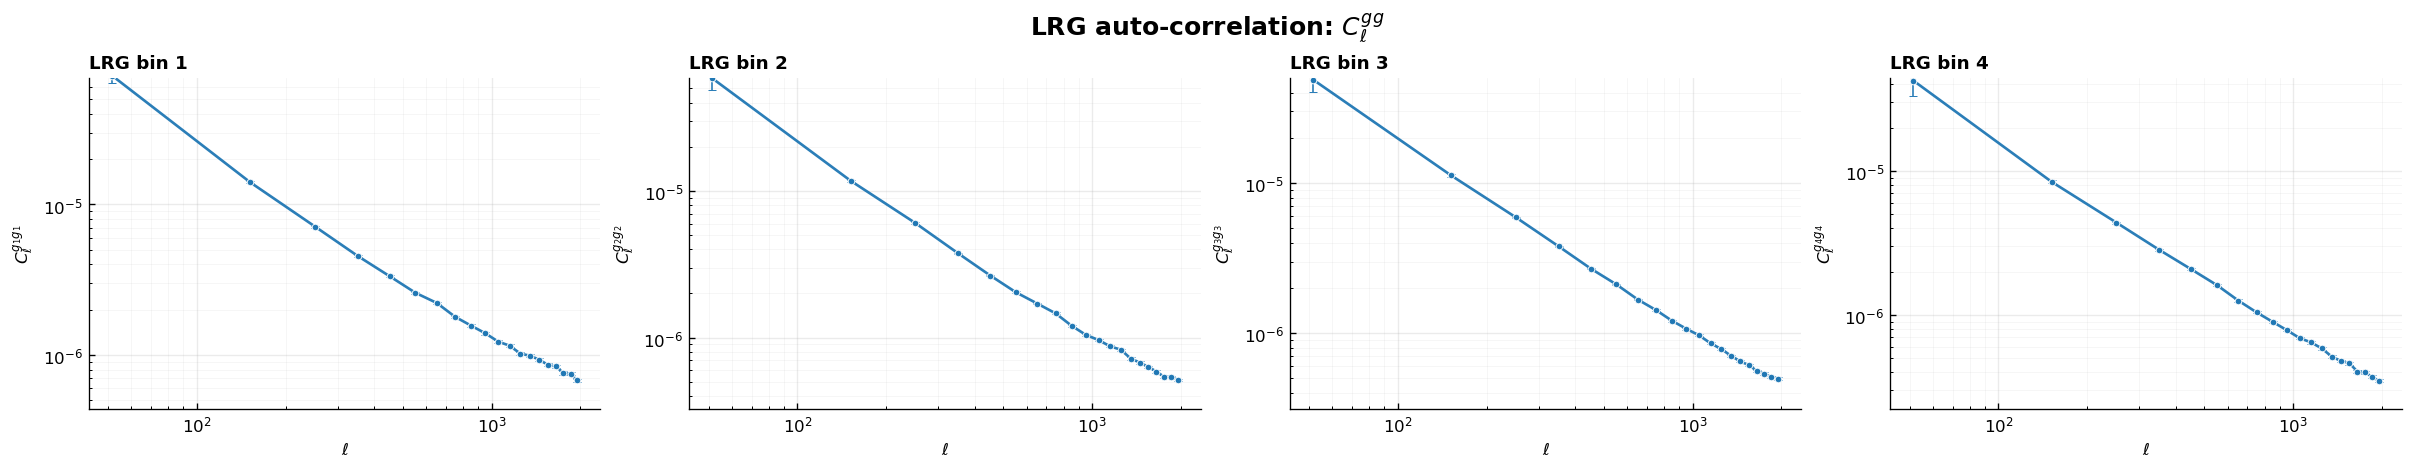

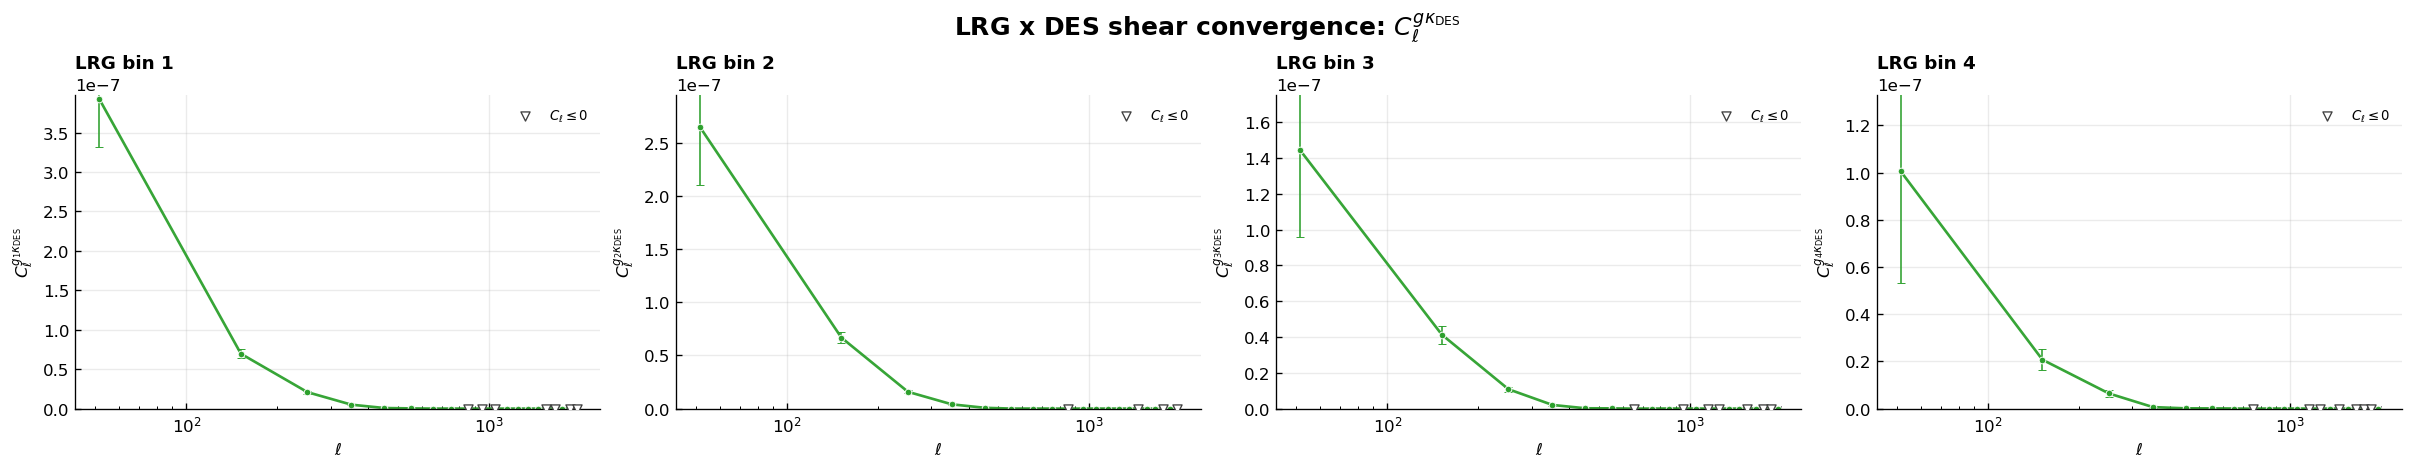

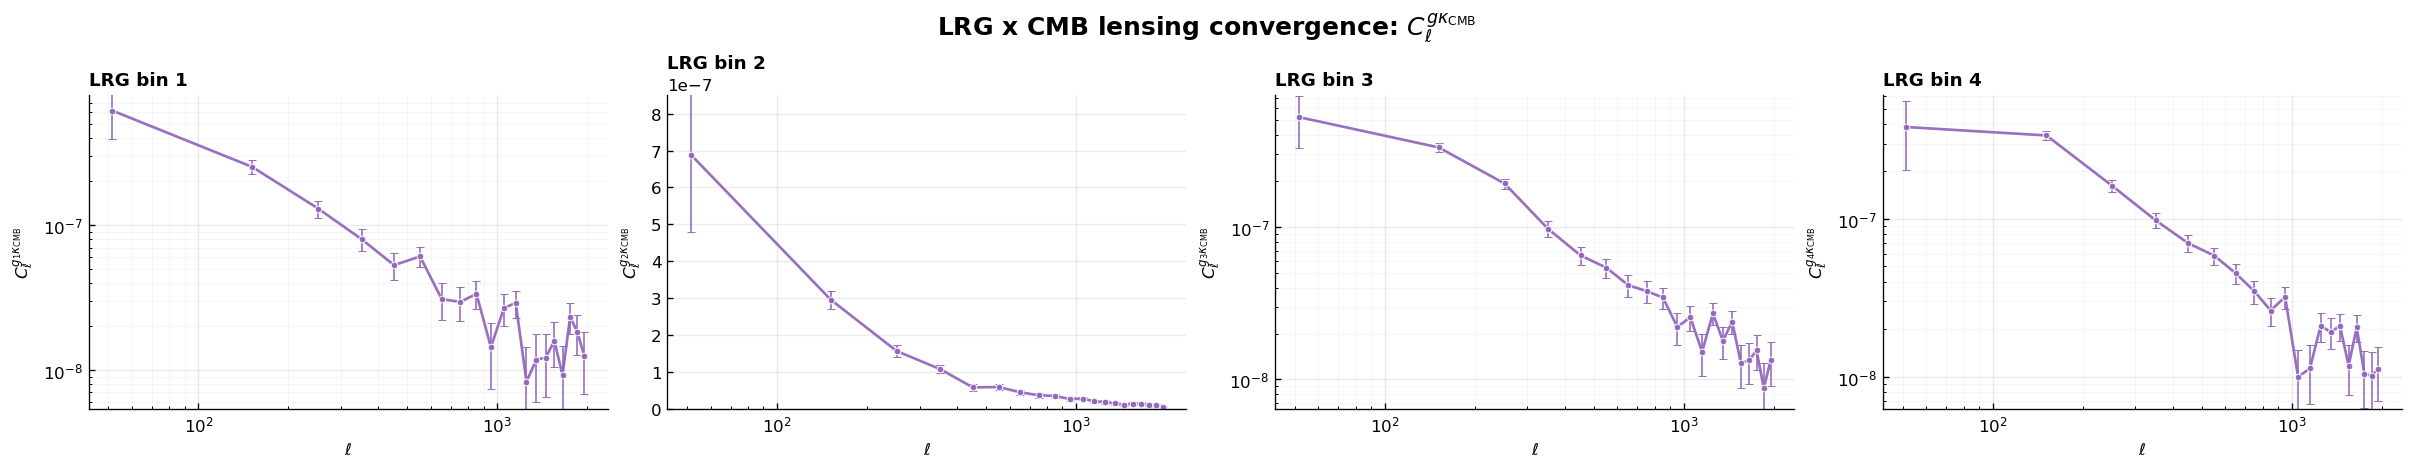

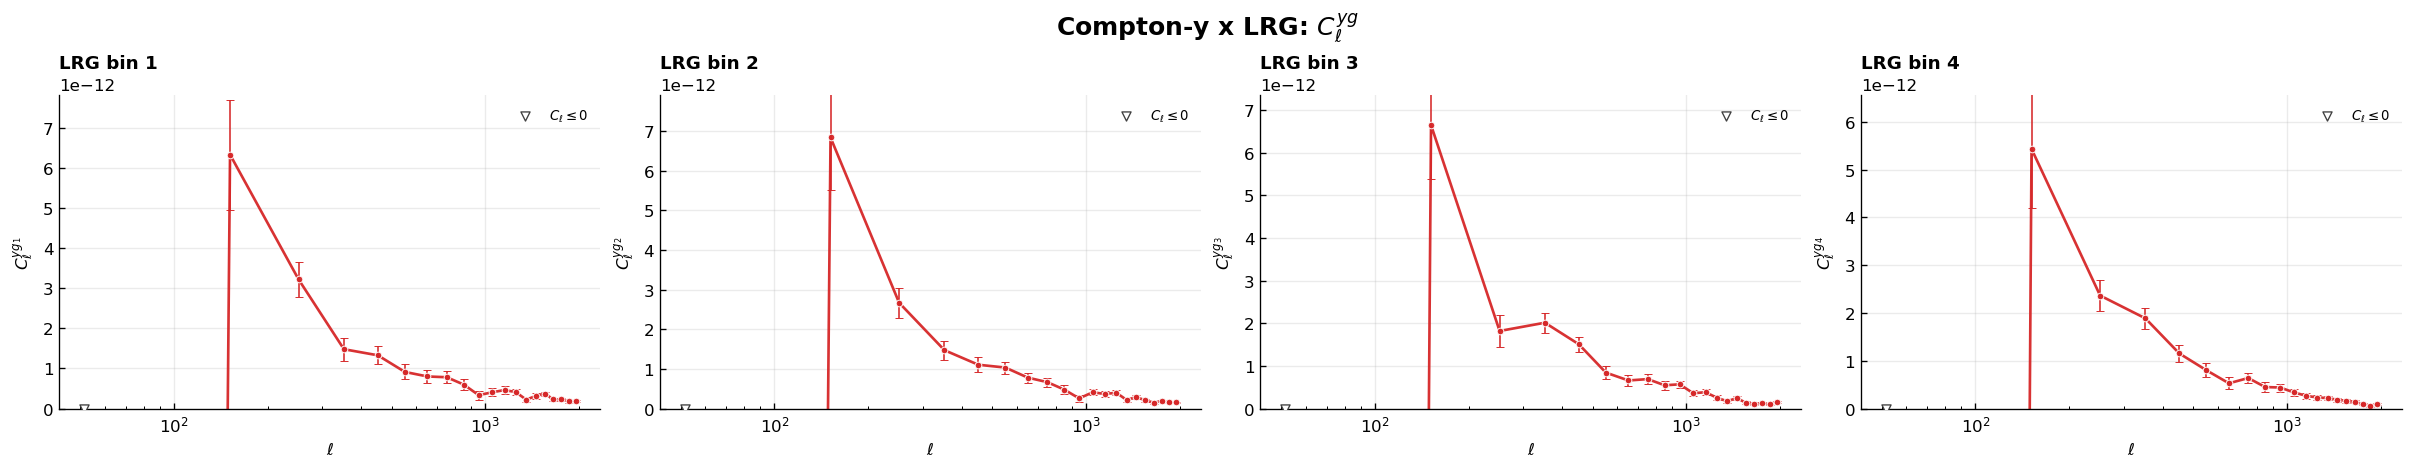

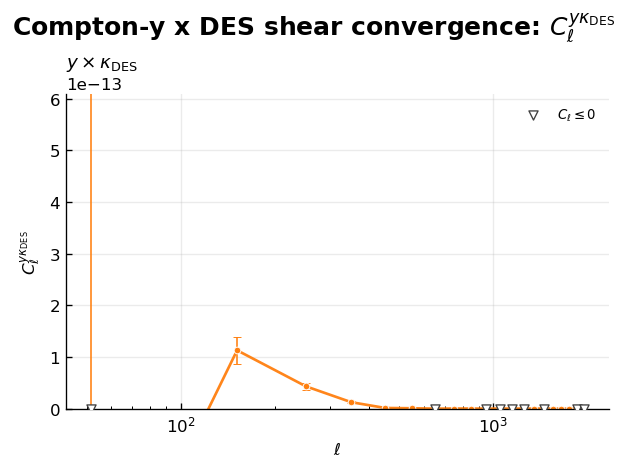

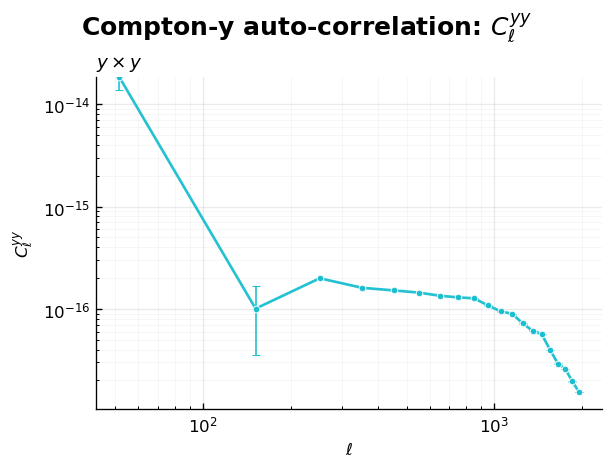

In [8]:
figures = plot_all_target_spectra(result)

## Save theory-comparison data product

The pickle stores `ell`, `spectra`, `covariance_blocks`, `joint`, `nz`, and `metadata`. Each entry under `spectra` contains `cl`, `cov`, `err`, and `bandpower_window`, so theory curves can be convolved to the measured bandpowers before comparison.

In [ ]:
saved_path = save_measurement_pickle(result, output_path)
print(f"Saved {saved_path}")

In [ ]:
print(result.keys())
print(result["spectra"].keys())
if result["joint"] is not None:
    print(result["joint"].keys())